In [19]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import astropy.io.fits as fits
#import asteroseismology as ast
from astropy.timeseries import LombScargle
pd.set_option('display.max_rows', None) 

import lightkurve as lk
import os
import csv
import scipy
from astropy.timeseries import LombScargle
import glob
%matplotlib inline
from astropy.time import Time

In [21]:
def smooth_median(x, y, window_size):
    binsize = np.median(np.diff(x))
    yf = scipy.ndimage.median_filter(y, int(np.ceil(window_size/binsize)))
    return yf
def smooth(x, y, windowSize, windowType, samplingInterval=None):
    '''
    Wrapping a sliding-average smooth function.

    Input:
    x: the independent variable of the time series.
    y: the dependent variable of the time series.
    windowSize: the period/width of the sliding window.
    windowType: flat/hanning/hamming/bartlett/blackman/gaussian
    samplingInterval: the time between adjacent sampling points.

    Output:
    yf: the smoothed time series with the exact same points as x.

    '''

    if len(x) != len(y): 
        raise ValueError("x and y must have equal size.")
        
    if samplingInterval is None: 
        samplingInterval = np.median(x[1:-1] - x[0:-2])
        
    xp = np.arange(np.min(x),np.max(x),samplingInterval)
    yp = np.interp(xp, x, y)
    
    window_len = int(windowSize/samplingInterval)
    if window_len % 2 == 0:
        window_len = window_len + 1
    
        
    ys = smooth_series(yp, window_len, window = windowType)
    yf = np.interp(x, xp, ys)

    return yf

def smooth_series(x, window_len = 11, window = "hanning"):
    # stole from https://scipy.github.io/old-wiki/pages/Cookbook/SignalSmooth
    if x.ndim != 1:
        raise ValueError("smooth only accepts 1 dimension arrays.")
    if x.size < window_len:
        raise ValueError("Input vector needs to be bigger than window size.")
    if window_len < 3:
        return x
    if not window in ["flat", "hanning", "hamming", "bartlett", "blackman", "gaussian"]:
        raise ValueError("Window is on of 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'")

    s = x #np.r_[x[window_len-1:0:-1],x,x[-1:-window_len:-1]]
    if window == "flat":
        w = np.ones(window_len,"d")
    elif window == "gaussian":
        w = gaussian(np.arange(-window_len*3, window_len*3,1), 
                    0, window_len, 1./(np.sqrt(2*np.pi)*window_len))
    else:
        w = eval("np."+window+"(window_len)") 
    
    y = np.convolve(w/w.sum(),s,mode="same")
    return y
def fourier(x, y, dy=None, oversampling=1, freqMin=None, freqMax=None, freq=None, return_val="power"):
    """
    Calculate the power spectrum density for a discrete time series.
    https://en.wikipedia.org/wiki/Spectral_density


    Input:
    x: array-like[N,]
        The time array.

    y: array-like[N,]
        The flux array.


    Optional input:
    dy: float, or array-like[N,]
        errors on y
    
    oversampling: float, default: 1
        The oversampling factor to control the frequency grid.
        The larger the number, the denser the grid.

    freqMin: float, default: frequency resolution

    freqMax: float, default: nyquist frequency


    Output:
    freq: np.array
        The frequency, in unit of [x]^-1.

    psd: np.array
        The power spectrum density, in unit of [y]^2/[x].
        https://en.wikipedia.org/wiki/Spectral_density


    Examples:
    >>> ts = np.load("flux.npy")
    >>> t = ts["time_d"]   # the time in day
    >>> f = ts["flux_mf"]   # the relative flux fluctuated around 1
    >>> f = (f-1)*1e6   # units, from 1 to parts per million (ppm)

    >>> freq, psd = fourier(t, f, return_val="psd_new")
    >>> freq = freq/(24*3600)*1e6   # c/d to muHz
    >>> psd = psd*(24*3600)*1e-6   # ppm^2/(c/d) to ppm^2/muHz

    """

    if not (return_val in ["psd_old", "periodogram", "power", "amplitude", "psd", "window"]):
        raise ValueError("return_val should be one of ['psd_old', 'periodogram', 'power', 'amplitude', 'psd_new', 'window'] ")

    Nx = len(x)
    dx = np.median(x[1:]-x[:-1]) 
    fs = 1.0/dx
    Tobs = dx*len(x)
    fnyq = 0.5*fs
    dfreq = fs/Nx
    #print(dfreq)

    if freqMin is None: freqMin = dfreq
    if freqMax is None: freqMax = fnyq

    if freq is None: freq = np.arange(freqMin, freqMax, dfreq/oversampling)
    #print(freq)
    if return_val == "psd_old":
        p = LombScargle(x, y, dy=dy).power(freq, normalization='psd')*dx*4.
    if return_val == "periodogram":
        # text book def of periodogram
        # don't think seismologists use this
        p = LombScargle(x, y, dy=dy).power(freq, normalization='psd')
    if return_val == "power":
        # normalized according to kb95
        # a sine wave with amplitude A will have peak height of A^2 in the power spectrum.
        p = LombScargle(x, y, dy=dy).power(freq, normalization='psd')/Nx*4.
        #print(p)
    if return_val == "amplitude":
        # normalized according to kb95
        # a sine wave with amplitude A will have peak height of A in the amp spectrum.
        p = np.sqrt(LombScargle(x, y, dy=dy).power(freq, normalization='psd')/Nx*4.)
    if return_val == "psd": 
        # normalized according to kb95
        # a sine wave with amplitude A will have peak height of A^2*Tobs in the power density spectrum.
        # should be equivalent to psd_old
        nu = 0.5*(freqMin+freqMax)
        freq_window = np.arange(freqMin, freqMax, dfreq/10)
        power_window = LombScargle(x, np.sin(2*np.pi*nu*x)).power(freq_window, normalization="psd")/Nx*4.
        Tobs = 1.0/np.sum(np.median(freq_window[1:]-freq_window[:-1])*power_window)
        p = (LombScargle(x, y, dy=dy).power(freq, normalization='psd')/Nx*4.)*Tobs
    if return_val == "window":
        # give spectral window
        nu = 0.5*(freqMin+freqMax)
        freq_window = np.arange(freqMin, freqMax, dfreq/10)
        power_window = LombScargle(x, np.sin(2*np.pi*nu*x)).power(freq_window, normalization="psd")/Nx*4.
        freq, p = freq_window-nu, power_window

    return freq, p
def background_estimate(ν1, ν2,freq,psd): #background estimate
    P1 = np.mean(psd[(freq >(ν1-100)) & (freq < (ν1+100))]) #these four lines estimate the alpha and beta
    P2 = np.mean(psd[(freq > (ν2-100)) & (freq < (ν2+100))])
    β =  np.log(P1/P2)/np.log(ν1/ν2)
    α = P1/ν1**β 

    #psd = psd/(α*freq**β)
    #psds = scipy.ndimage.gaussian_filter(psd, Dnu*0.01/np.median(np.diff(freq)))
    
    psd_background=(α * freq**β)
    if freq.min() > (ν1 + 100) or freq.max() < (ν2 - 100):
        raise ValueError(f"PSD for KIC doesn't span full 100–10,000 µHz")
    return psd_background #plotting the alpha and beta


In [23]:
def fit_background(freq, power, power_smooth, numax, fnyq, NHarvey=1, if_return_oscillation=False):
    
    def spectral_response(x, fnyq):
        sincfunctionarg = (np.pi/2.0)*x/fnyq
        response = (np.sin(sincfunctionarg)/sincfunctionarg)**2.0
        return response

    def standard_background_model(x, params, fnyq, NHarvey=1, if_return_oscillation=True):
        flatNoiseLevel, heightOsc, numax, widthOsc = params[0:4]
        power_model = np.zeros(len(x))
        zeta = 2.0 * 2.0**0.5 / np.pi
        for iHarvey in range(NHarvey):
            ampHarvey, freqHarvey, powerHarvey = params[iHarvey*3+4:iHarvey*3+7]
            power_model += zeta * ampHarvey**2.0 / (freqHarvey * (1 + (x/freqHarvey)**powerHarvey))
        if if_return_oscillation:
            power_model += heightOsc * np.exp(-1.0*(numax - x)**2 / (2.0 * widthOsc**2.0))
        power_model *= spectral_response(x, fnyq)
        power_model += flatNoiseLevel
        return power_model

    def guess_background_params(freq, power_smooth, numax, NHarvey=1):
        zeta = 2*2**0.5/np.pi
        flatNoiseLevel = np.median(power_smooth[int(len(freq)*0.9):])
        heightOsc = power_smooth[np.argmin(np.abs(freq - numax))]
        widthOsc = 3.0 * (0.263 * numax**0.772)
        freqHarvey_solar = np.array([2440.5672465, 735.4653975, 24.298031575])
        numax_solar = 3050
        freqHarvey = numax / numax_solar * freqHarvey_solar
        powerHarvey = np.ones(3) * 4.
        ampHarvey = np.zeros(3)
        for iHarvey in range(3):
            ampHarvey[iHarvey] = (power_smooth[np.argmin(np.abs(freq - freqHarvey[iHarvey]))] * 2 / zeta * freqHarvey[iHarvey])**0.5

        paramsInit = [flatNoiseLevel, heightOsc, numax, widthOsc,
                      ampHarvey[0], freqHarvey[0], powerHarvey[0]]
        paramsBounds = [
            [flatNoiseLevel*0.1, flatNoiseLevel*1.1],
            [heightOsc*0.2, heightOsc*5.0],
            [numax*0.5, numax*2.0],
            [widthOsc*0.1, widthOsc*4.0],
            [ampHarvey[0]*0.3, ampHarvey[0]*3.0],
            [freqHarvey[0]*0.2, freqHarvey[0]*5.0],
            [2.0, 8.0]
        ]
        return paramsInit[:4+NHarvey*3], paramsBounds[:4+NHarvey*3]

    # Get initial guesses
    paramsInit, paramsBounds = guess_background_params(freq, power_smooth, numax, NHarvey)

    def func(params):
        model = standard_background_model(freq, params, fnyq, NHarvey, if_return_oscillation=True)
        return np.sum(np.log(model) + power / model)

    # Optimize
    minimizer_kwargs = {"bounds": paramsBounds}
    res = scipy.optimize.minimize(func, paramsInit, **minimizer_kwargs)
    params_best = res.x
    background = standard_background_model(freq, params_best, fnyq, NHarvey, if_return_oscillation)
    return params_best, background


solar irradiance data from SOHO/VIRGO can be downloaded from 
https://irfu.cea.fr/en/Phocea/Vie_des_labos/Ast/ast_technique.php?id_ast=3581

In [26]:
(fits.getheader('solar/SPM_green_intensity_series.fits'))
#print(fits.getheader('solar/SPM_red_intensity_series.fits'))

SIMPLE  =                    T / Written by IDL:  Wed Jun  3 12:28:51 2015      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    1 / Number of data axes                            
NAXIS1  =              9450720 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2015-05-20'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    
DATA    = 'SOHO/VIRGO SPM-green intensity series' /Solar oscillations           
JDSTART =        2450184.49936 /Starting date (julian day)                      
JDEND   =        2456747.49887 /Ending date (julian day)                        
INSTRUME= 'VIRGO/SPM green'    /Instrument                                      
FILENAME= 'SPM_green_intensi

/var/folders/zs/25gg7x7j44957llymv4b35d40000gn/T/ipykernel_977/805293870.py:95: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(9,5))


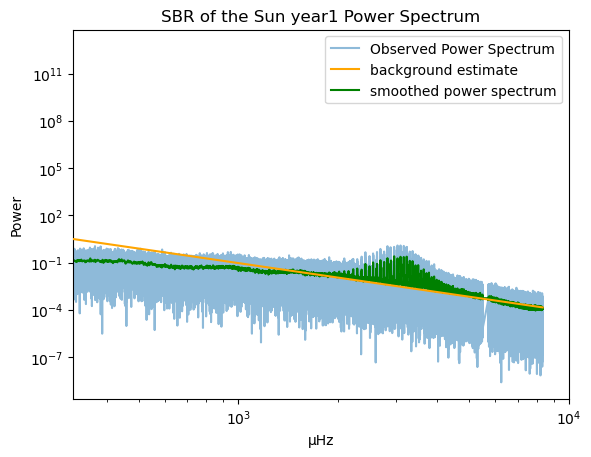

<Figure size 640x480 with 0 Axes>

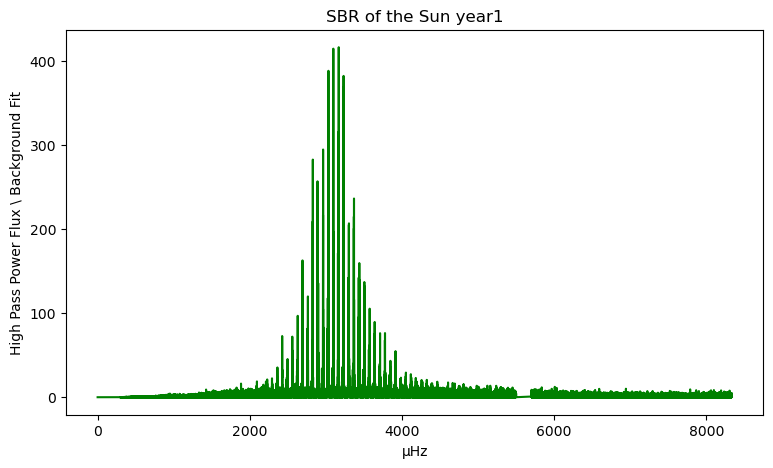

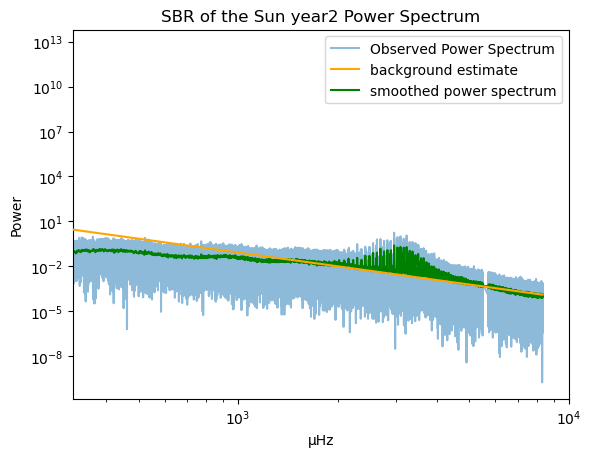

<Figure size 640x480 with 0 Axes>

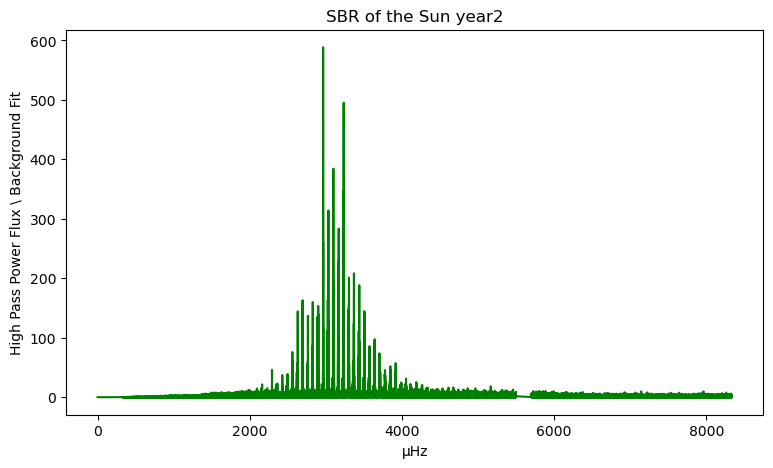

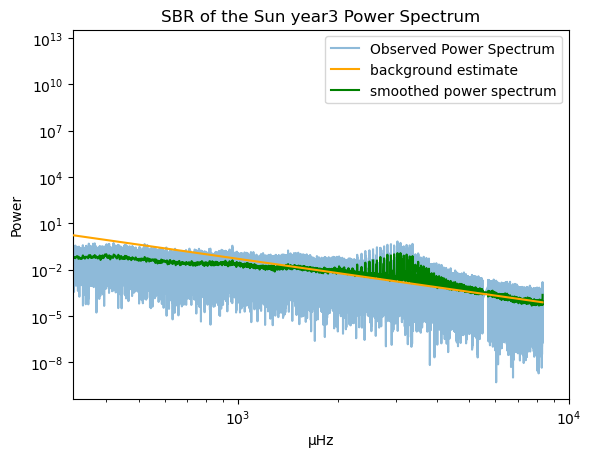

<Figure size 640x480 with 0 Axes>

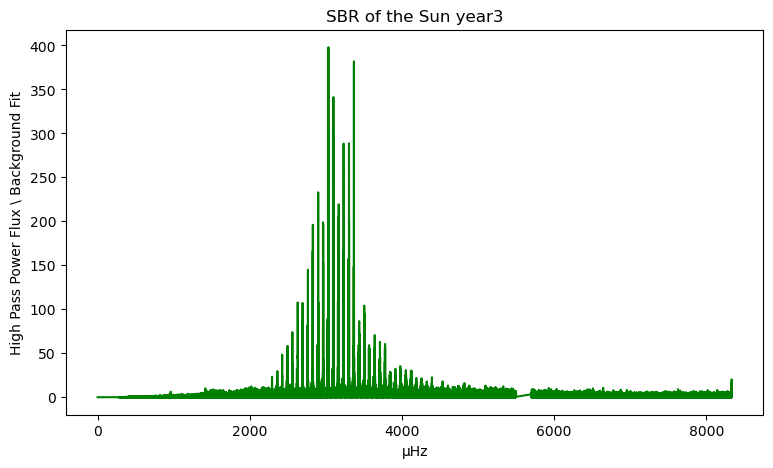

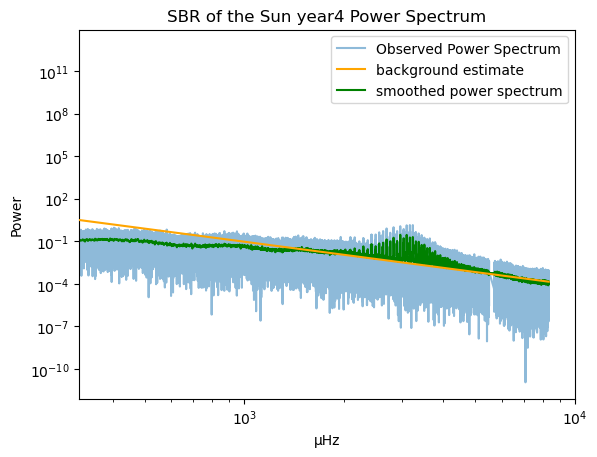

<Figure size 640x480 with 0 Axes>

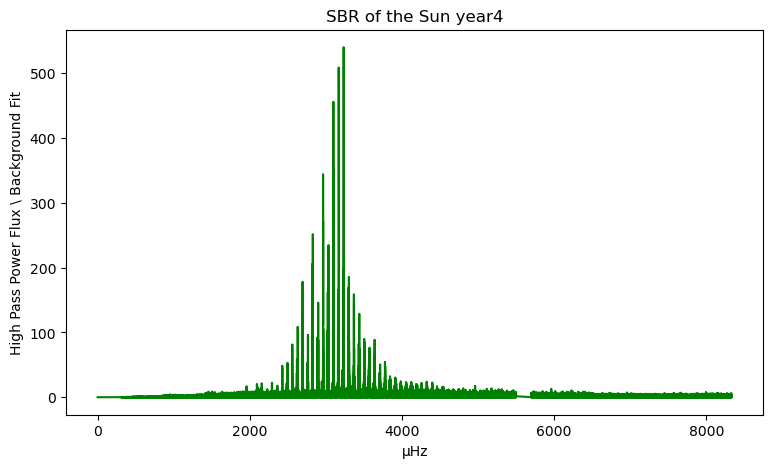

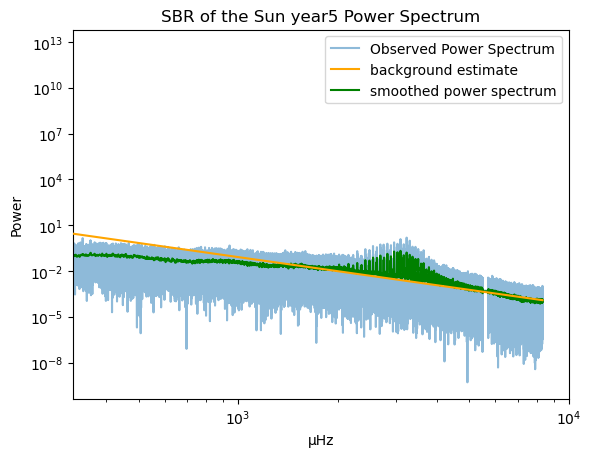

<Figure size 640x480 with 0 Axes>

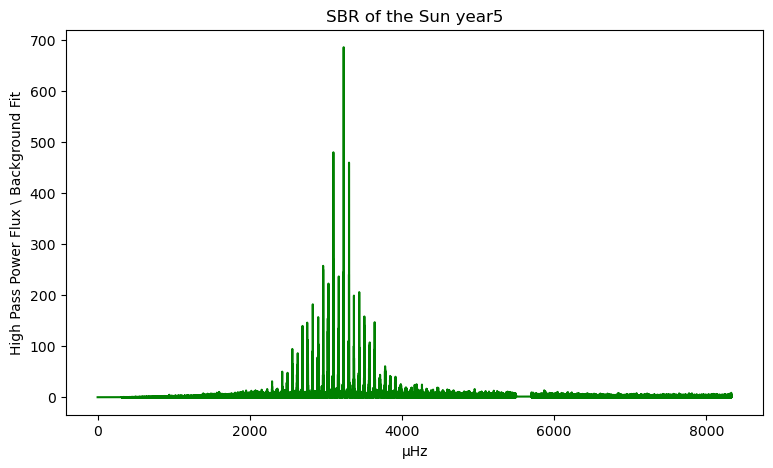

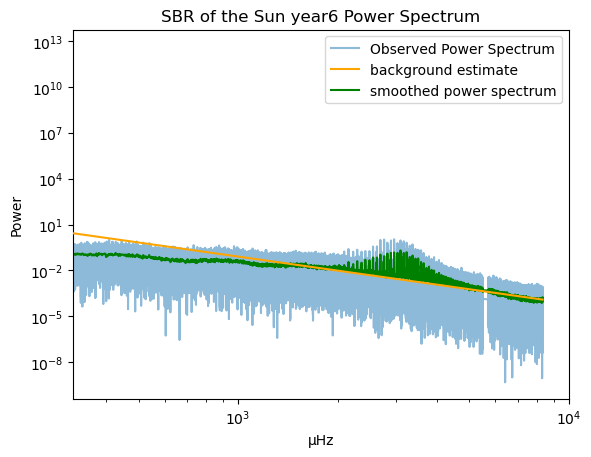

<Figure size 640x480 with 0 Axes>

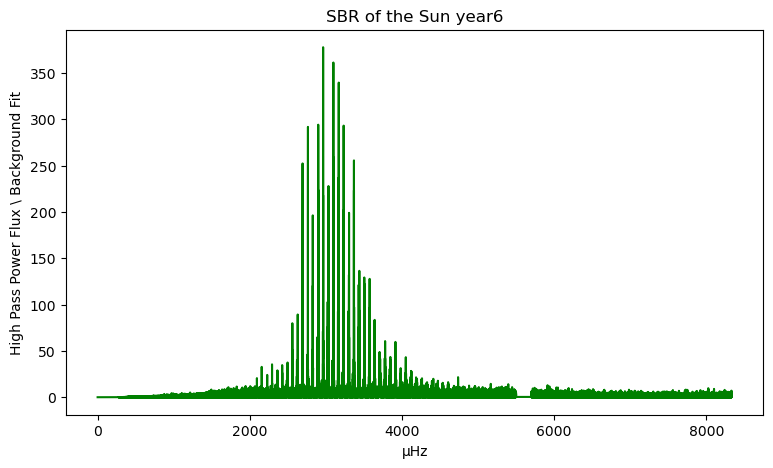

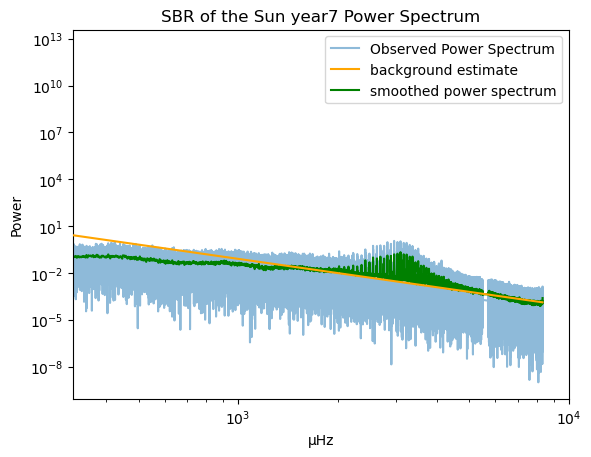

<Figure size 640x480 with 0 Axes>

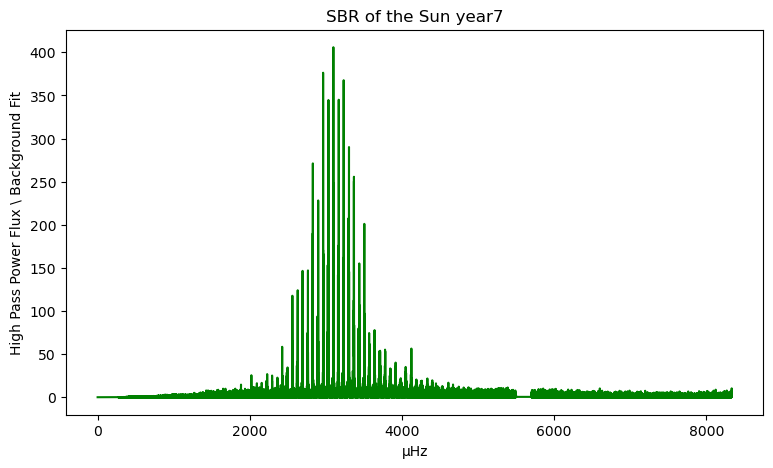

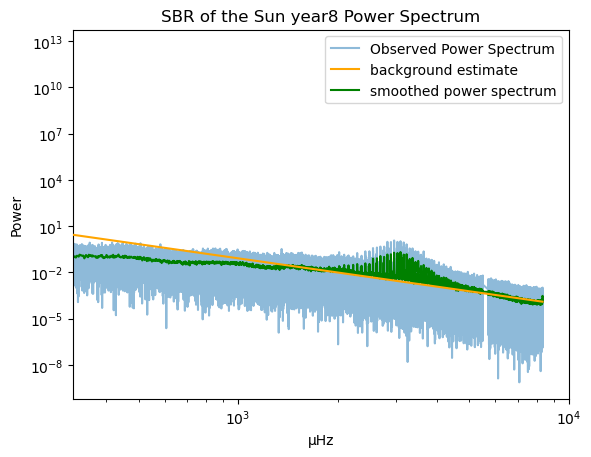

<Figure size 640x480 with 0 Axes>

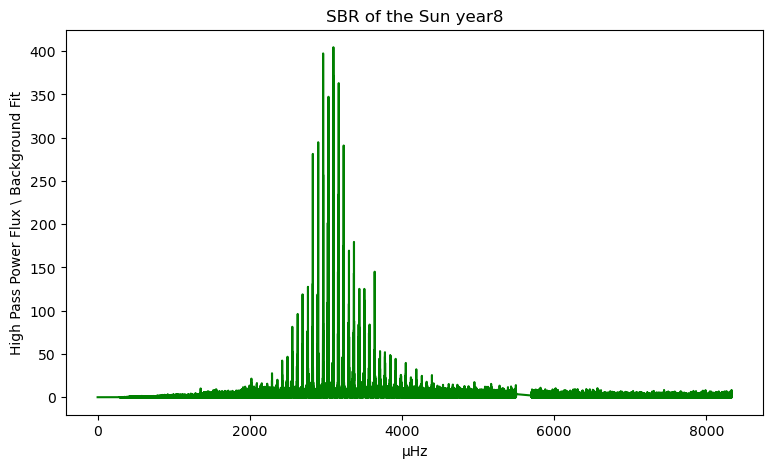

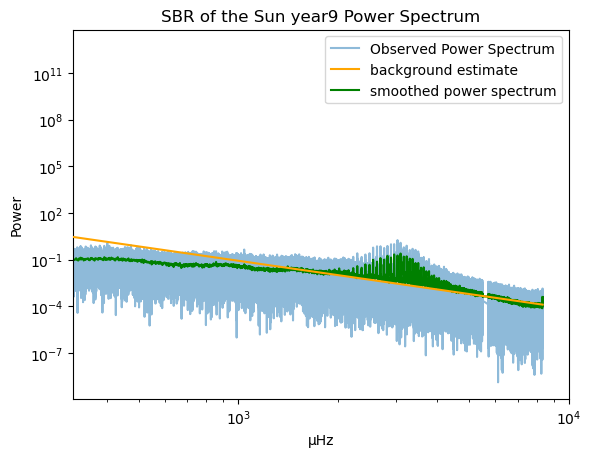

<Figure size 640x480 with 0 Axes>

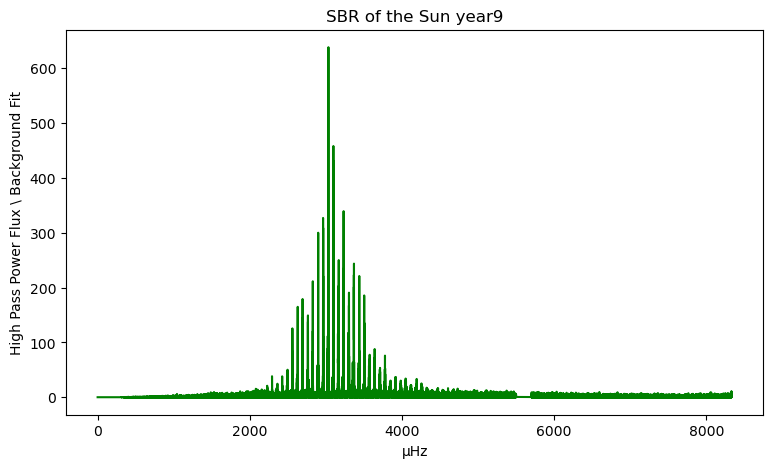

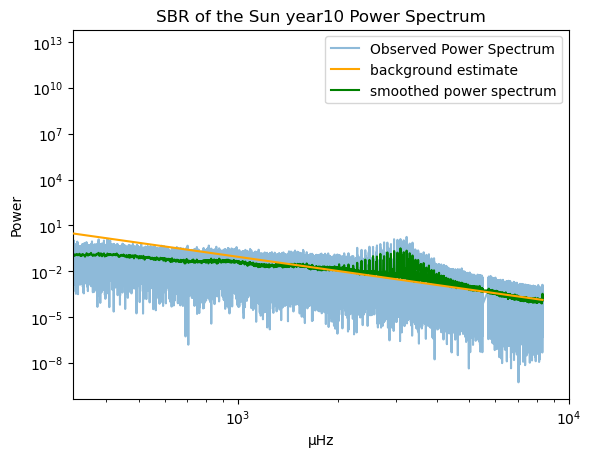

<Figure size 640x480 with 0 Axes>

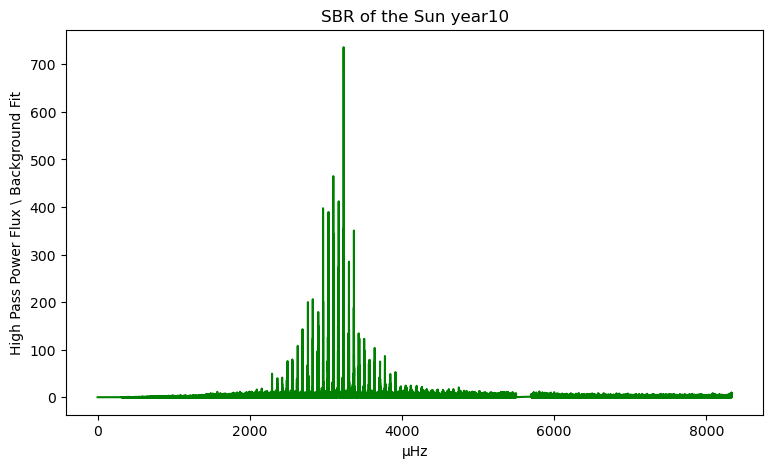

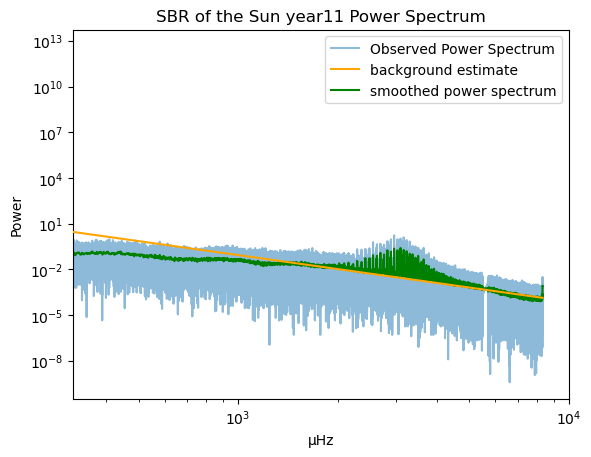

<Figure size 640x480 with 0 Axes>

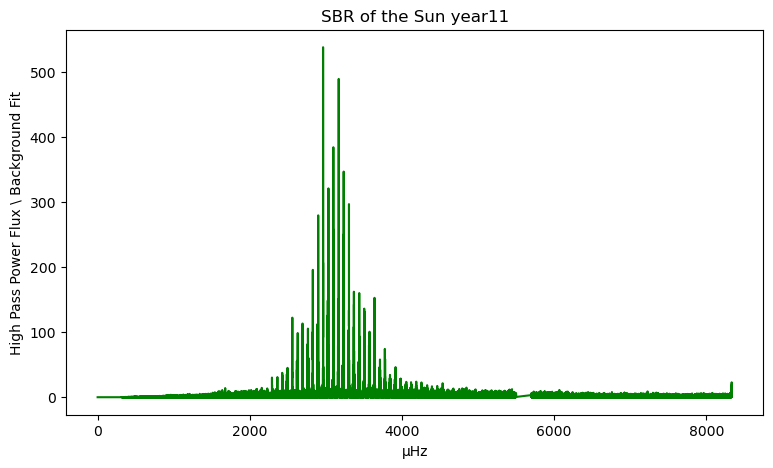

In [29]:
green = fits.getdata('solar/SPM_green_intensity_series.fits')
red = fits.getdata('solar/SPM_red_intensity_series.fits')

all_freqs = []
all_powers = []
all_sbrs = []
all_bg=[]
all_psds=[]


Tstart = 2450184.49936 #1996
Tend = 2456747.49887 #2014
time = Tstart + np.arange(0, len(green)) * 60. / (24*3600.)
flux = green * 0.785 + red * 0.215 # weighted average to roughly match Kepler response function. unclear about the unit, is it ppm?

low_pass=smooth_median(time-Tstart,flux,1/24)



 
for i in range(11):  # Years 0–10 → Year 1–11
    stars=pd.read_excel('MOTHERSHIP/lund+17-legacy-table1 (1).xlsx', engine='openpyxl')
    star=stars[stars['KIC']=='Sun']
    year_num=i+1
    start_day = Tstart + (i*365.25)
    end_day = Tstart +((i+1)*365.25)

    mask =(time>=start_day) & (time<end_day)

    t_year = time[mask]
    f_year = flux[mask]
    lp_year = low_pass[mask]
    hp_year=f_year-lp_year
    
    
    
    start_date = Time(t_year[0], format='jd', scale='utc').isot[:10] #taking the first 10 characters of this ISO strong, it drops the time of day
    end_date   = Time(t_year[-1], format='jd', scale='utc').isot[:10] #taking the last one and converting it againwha

    high_pass_pow=fourier(t_year,hp_year,dy=None,oversampling=1,
                             freqMin=None,freqMax=None,freq=None,return_val='power')

    high_pass_pow=list(high_pass_pow)
    freq=high_pass_pow[0]*11.575
    power=high_pass_pow[1]
    
    mask_freq= (5500 > freq) | (freq > 5700)
    freq=freq[mask_freq]
    power=power[mask_freq]
    
    high_pass_pow=[freq, power]
    #smooth_star=smooth(high_pass_pow[0],high_pass_pow[1],3,'bartlett',samplingInterval=None)

    numax_star = 3090 #how should i get the numax? #use the one on desktop 
    Dnu_star = 135.1
    psd_bg=background_estimate(numax_star*.5, numax_star*2,high_pass_pow[0],high_pass_pow[1])


    fnyq_star = 1/(2*60)*1e6  # microHz
    freq_star = high_pass_pow[0]
    power_star = high_pass_pow[1]
    #powers_star = smooth_star

    psds = scipy.ndimage.gaussian_filter(power_star, Dnu_star*0.005/np.median(np.diff(high_pass_pow[0])))

    psds_arr=np.array([freq_star,psds]).T
    np.save(f'MOTHERSHIP/all_psds_data/psds_sun_{start_date}_to_{end_date}',psds_arr)


    #params, background_fit = fit_background(freq_star, power_star,
                                #powers_star, numax_star, fnyq_star)

   

    plt.figure()
    plt.plot(high_pass_pow[0],high_pass_pow[1],label='Observed Power Spectrum',alpha=.5)
    plt.plot(high_pass_pow[0],psd_bg,label='background estimate',color='orange',zorder=100)
    plt.plot(high_pass_pow[0],psds,label='smoothed power spectrum',color='green')
    #plt.plot(high_pass_pow[0], background_fit, label="Fitted Background Model", linewidth=2)
    #plt.plot(freq_plot,psd_plot,label='Smoothed Power Spectrum',color='green')
    plt.title(f'Sun year{year_num}')


    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('\u03bcHz')
    plt.ylabel('Power')
    plt.title(f'SBR of the Sun year{year_num} Power Spectrum')
    plt.legend()
    plt.xlim(10**2.5,10**4)
    plt.savefig(f'MOTHERSHIP/all_SBR_figures/power_figure_sun_{start_date}_to_{end_date}.jpeg')

    plt.figure()
    SBR=high_pass_pow[1]/psd_bg
    plt.figure(figsize=(9,5))
    plt.plot(high_pass_pow[0], SBR,color='green')
    plt.title(f'SBR of the Sun year{year_num}')
    plt.xlabel('\u03bcHz')
    plt.ylabel('High Pass Power Flux \ Background Fit')
    #plt.ylim(0,30)
    #plt.xlim(1000,2000)
    plt.savefig(f'MOTHERSHIP/all_SBR_figures/SBR_figure_sun_{start_date}_to_{end_date}.jpeg')

    arr=np.array([high_pass_pow[0],SBR]).T #make array with two rows, the .T transposes the array to be 2 columns instead of 2 rows 
    np.save(f'MOTHERSHIP/all_SBR_data/SBR_sun_{start_date}_to_{end_date}.npy',arr)

    all_freqs.append(high_pass_pow[0])
    all_powers.append(high_pass_pow[1])
    all_sbrs.append(SBR)
    all_bg.append(psd_bg)
    all_psds.append(psds)
    
    
    #data= pd.DataFrame({'time': t_year,'flux': f_year,'low_pass': lp_year})


    #data.to_csv(f'MOTHERSHIP/solar_lowpass_year_{i+1}.csv', index=False)




    




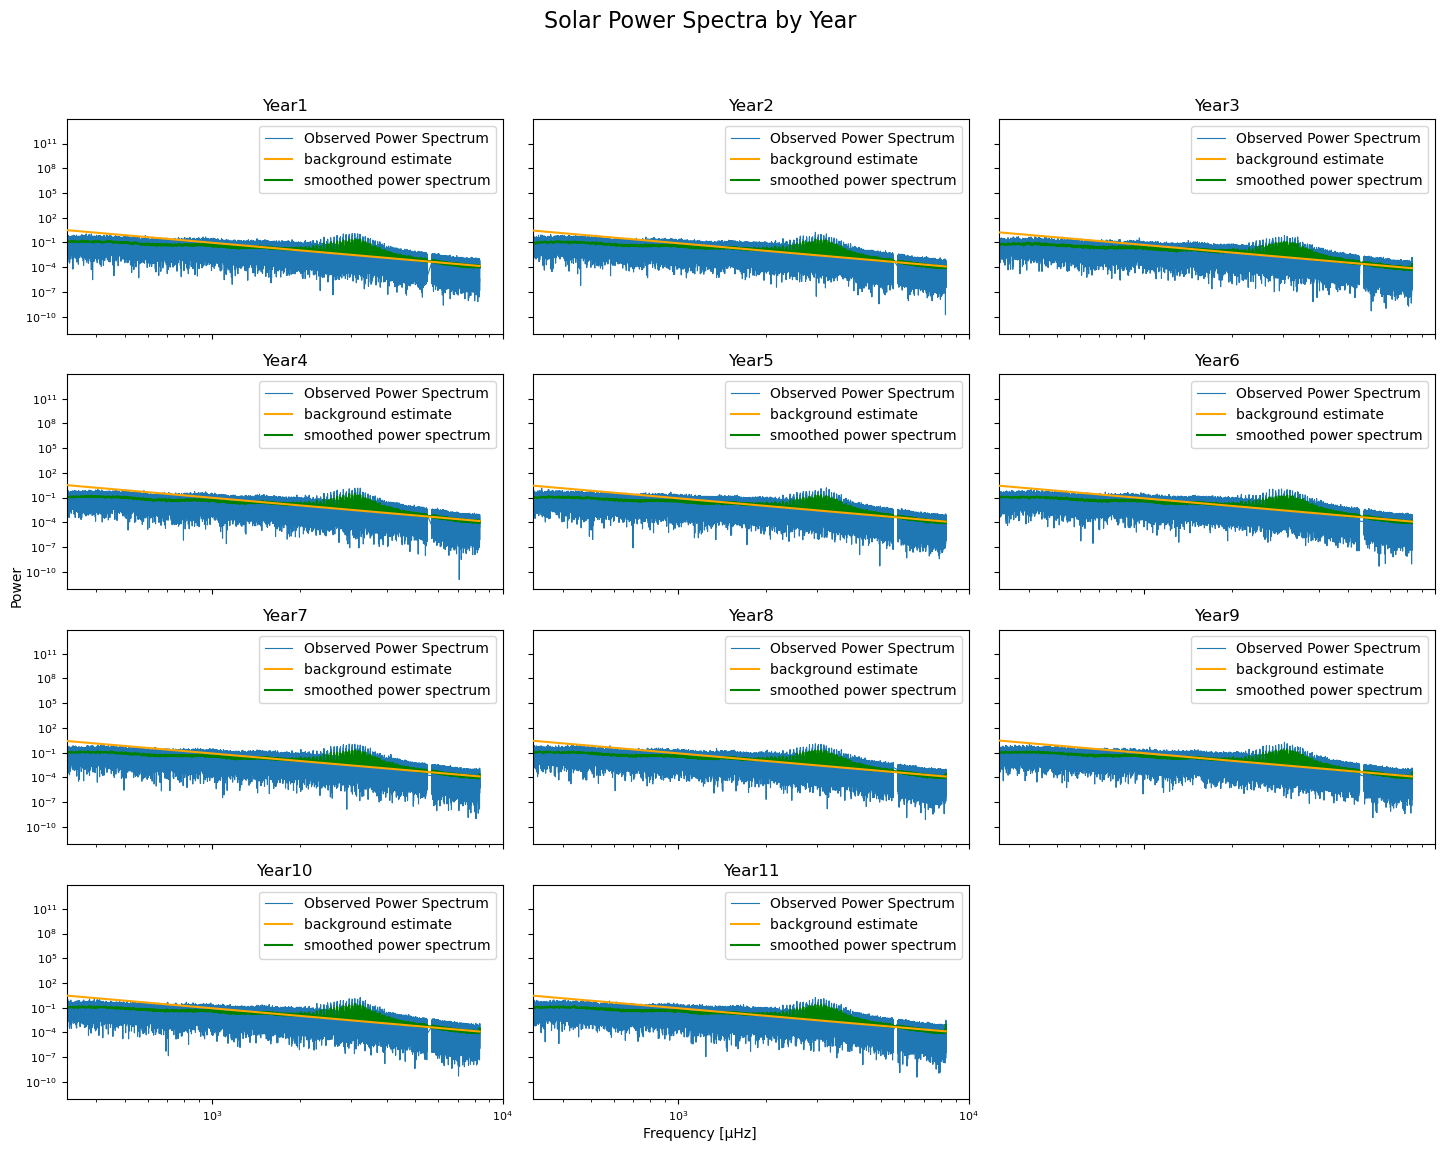

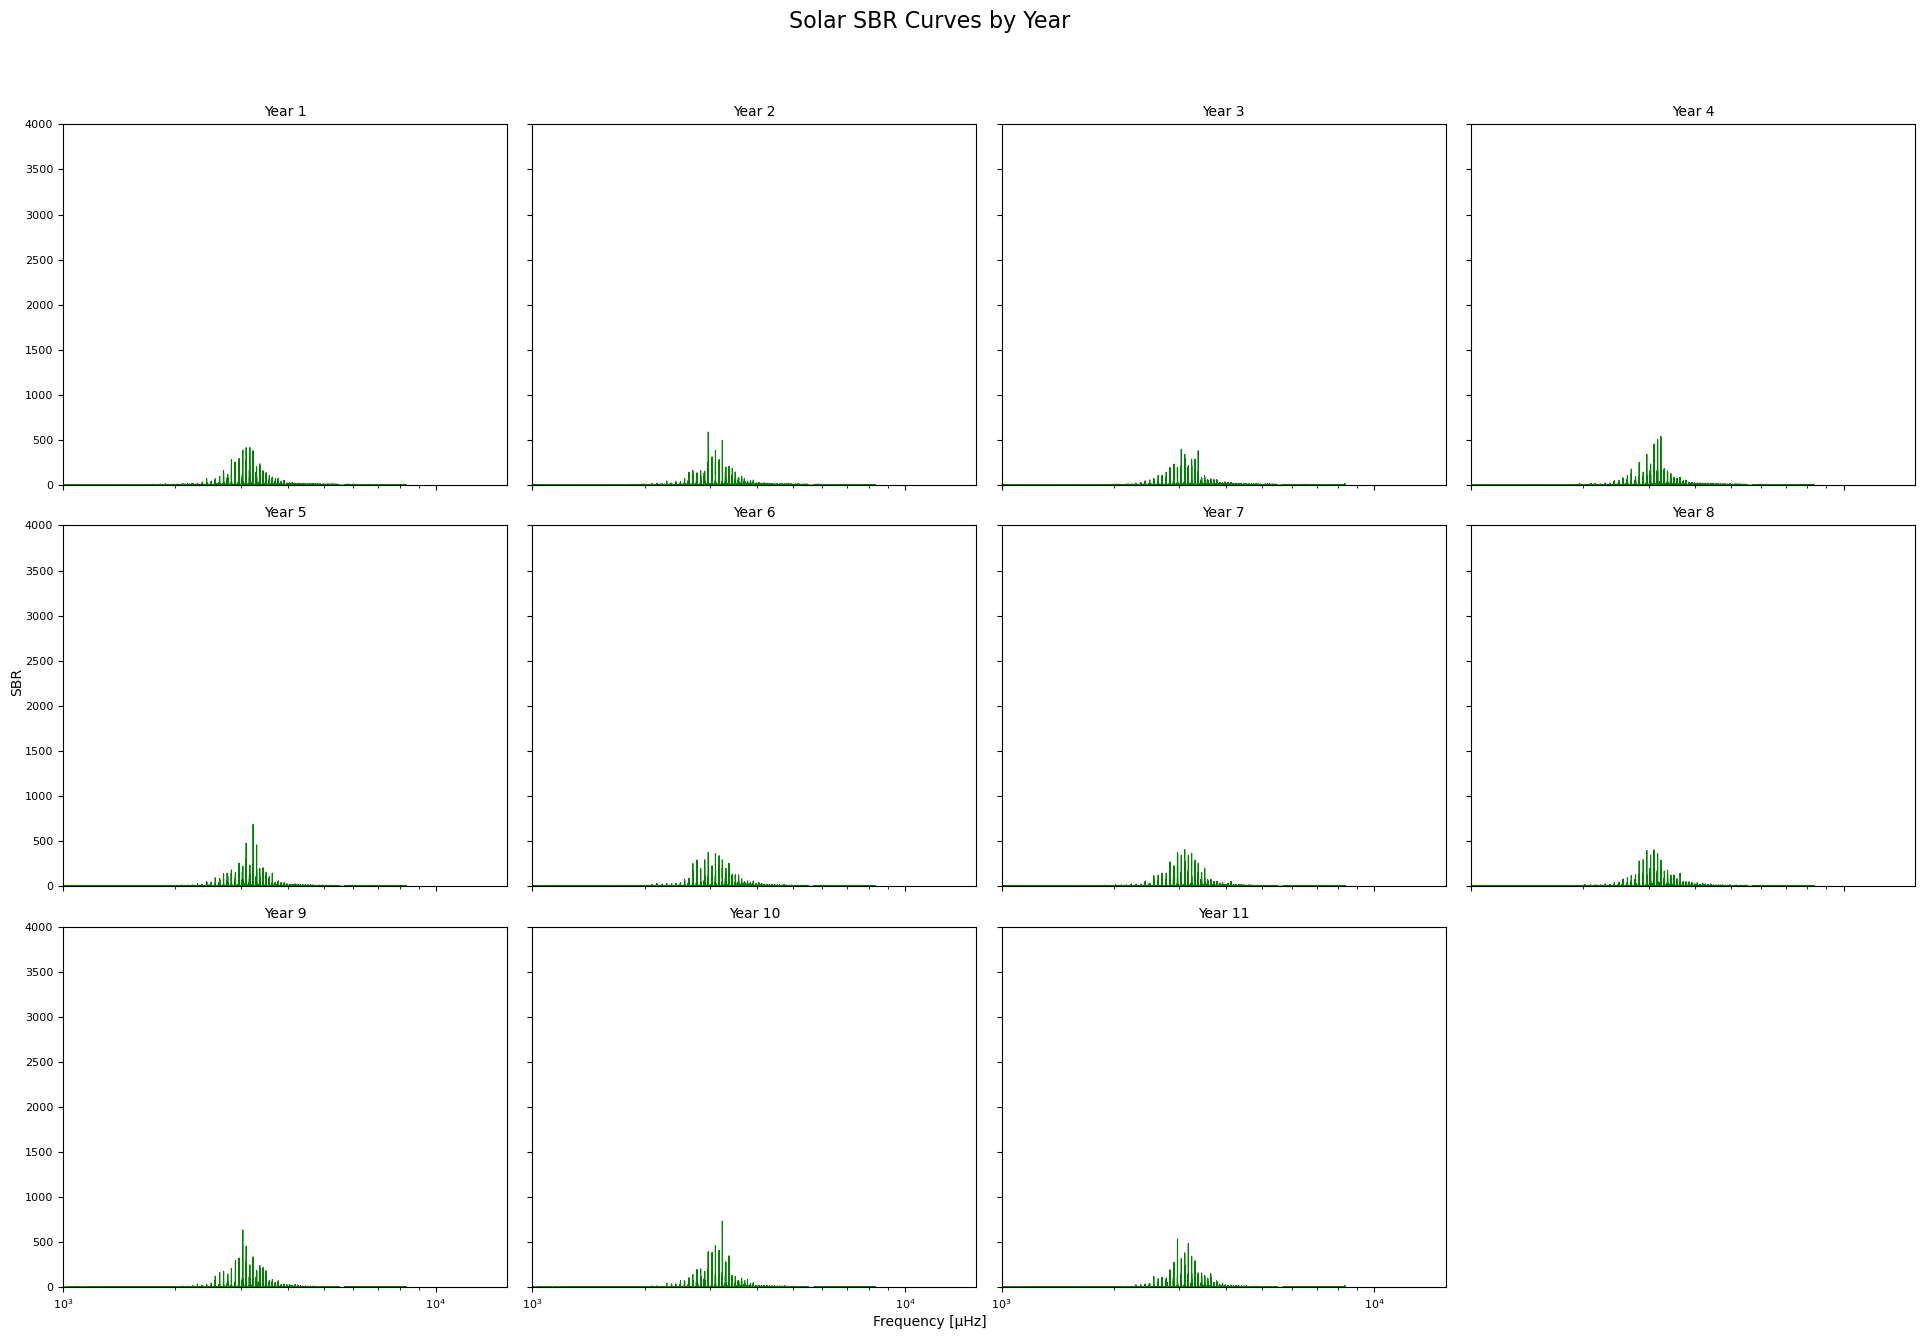

In [14]:
fig, axs = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(11):
    year_num=i+1
    axs[i].plot(all_freqs[i], all_powers[i], lw=0.8, label='Observed Power Spectrum')
    axs[i].plot(all_freqs[i], all_bg[i], label='background estimate',color='orange',zorder=100)
    axs[i].plot(all_freqs[i], all_psds[i], label='smoothed power spectrum',color='green')
    axs[i].set_title(f'Year {i+1}', fontsize=10)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].tick_params(labelsize=8)
    axs[i].legend()
    axs[i].set_title(f'Year{year_num}')
    axs[i].set_xlim(10**2.5,10**4)
    
    
axs[11].axis('off')

fig.suptitle('Solar Power Spectra by Year', fontsize=16)
fig.text(0.5, 0.04, 'Frequency [μHz]', ha='center')
fig.text(0.04, 0.5, 'Power', va='center', rotation='vertical')
plt.tight_layout(rect=[0.04, 0.04, 1, 0.95])
plt.savefig('MOTHERSHIP/all_SBR_figures/subplot_power_spectra.pdf')
plt.show()


fig, axs = plt.subplots(3, 4, figsize=(20, 14), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(11):
    axs[i].plot(all_freqs[i], all_sbrs[i], color='green', lw=0.8)
    axs[i].set_title(f'Year {i+1}', fontsize=10)
    axs[i].set_xscale('log')
    axs[i].tick_params(labelsize=8)
    axs[i].set_xlim(1000)
    axs[i].set_ylim(0,4000)


axs[11].axis('off')

fig.suptitle('Solar SBR Curves by Year', fontsize=16)
fig.text(0.5, 0.04, 'Frequency [μHz]', ha='center')
fig.text(0.04, 0.5, 'SBR', va='center', rotation='vertical')
plt.tight_layout(rect=[0.04, 0.04, 1, 0.95])
plt.savefig('MOTHERSHIP/all_SBR_figures/subplot_SBR_curves.pdf')
plt.show()



In [15]:
# pd.DataFrame({'time[JD]': time, 'flux[ppm]': flux}).to_csv('solar_time_series.csv', index=False)

from IPython.display import FileLink

(FileLink('MOTHERSHIP/all_SBR_figures/subplot_power_spectra.pdf'))




/Users/ailee/399/Official/MOTHERSHIP/all_SBR_figures/subplot_power_spectra.pdf

In [79]:
FileLink('MOTHERSHIP/all_SBR_figures/subplot_SBR_curves.pdf')

/data/sarek1/aknauff/MOTHERSHIP/all_SBR_figures/subplot_SBR_curves.pdf

/usr/lib/python3.6/site-packages/IPython/core/pylabtools.py:122: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


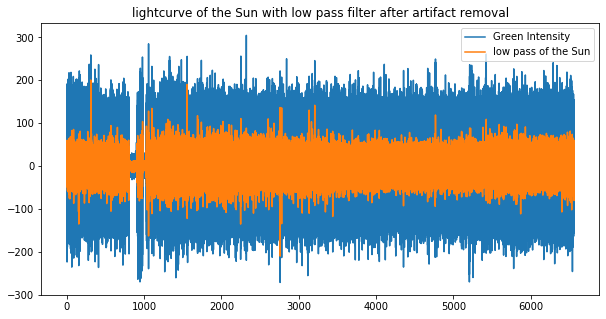

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(time-Tstart, flux, label='Green Intensity')
plt.plot(time-Tstart,low_pass,label='low pass of the Sun',zorder=100)

plt.title('lightcurve of the Sun with low pass filter after artifact removal')
plt.savefig('MOTHERSHIP/all_SBR_figures/time_series_figure_sun.jpeg')
plt.legend()

plt.show()

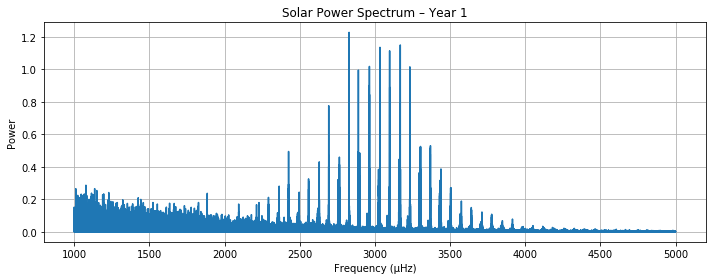

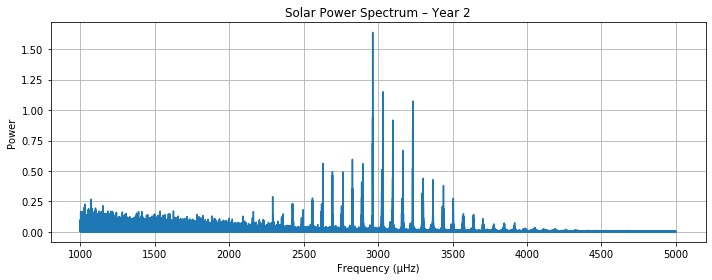

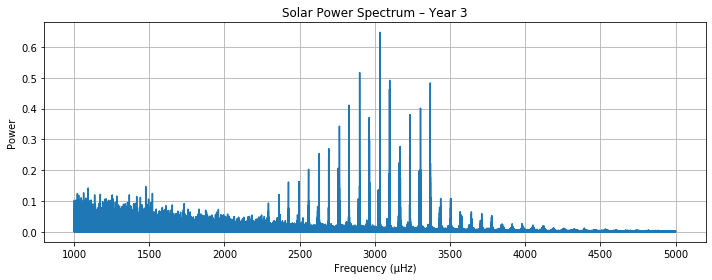

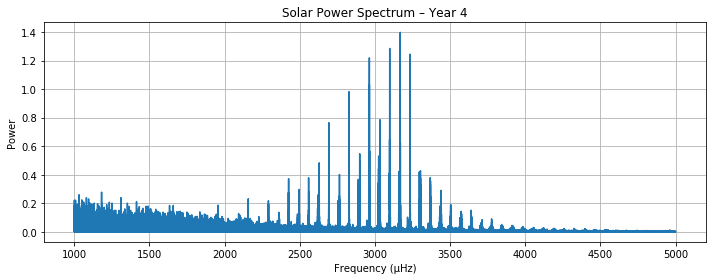

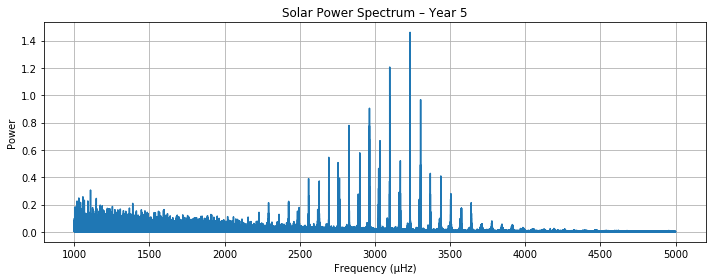

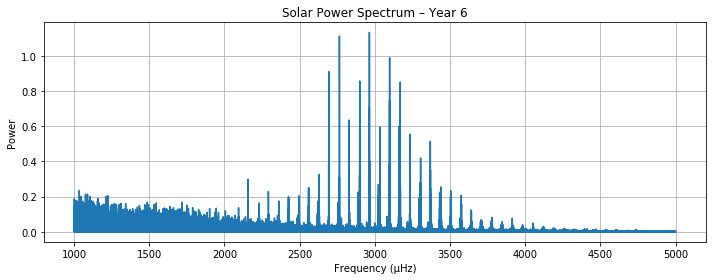

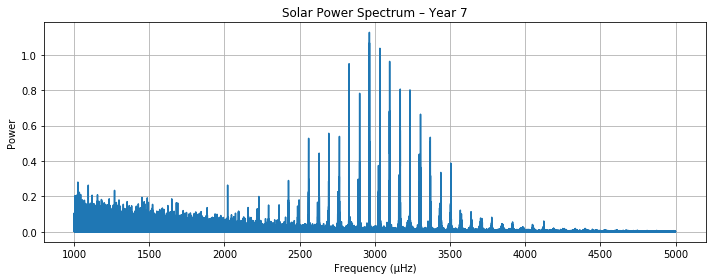

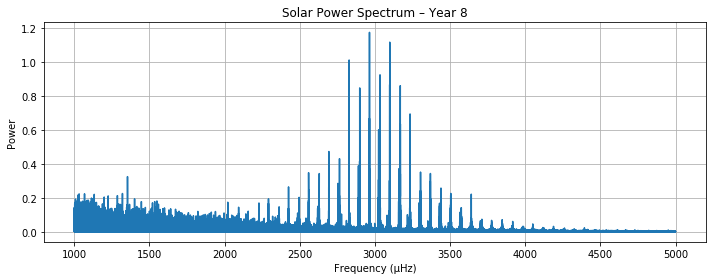

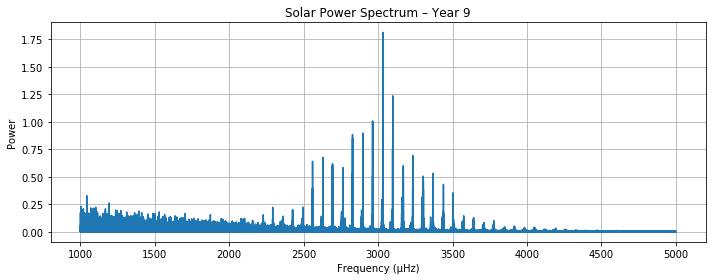

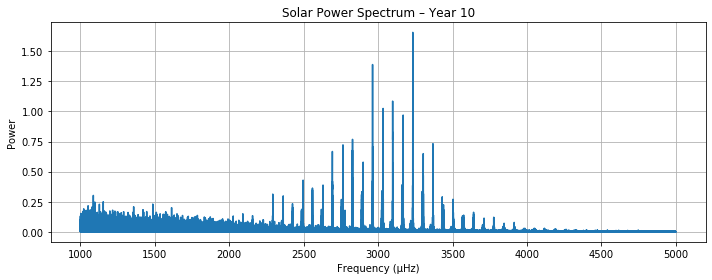

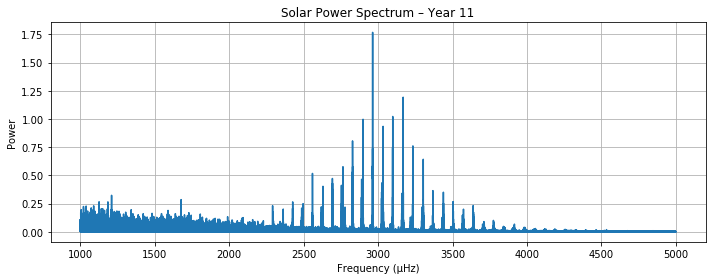

In [28]:
for i in range (1,12):
   # i = 1 # year index
    m = time > (Tstart + (i - 1) * 365.25)
    m &= time < (Tstart + i * 365.25)

    freq, power = fourier(time[m], flux[m], return_val='power', freqMin=1000/11.574, freqMax=5000/11.574)
    freq *= 11.574 

    plt.figure(figsize=(10, 4))
    plt.plot(freq, power)
    plt.xlabel("Frequency (µHz)")
    plt.ylabel("Power")
    plt.title(f"Solar Power Spectrum – Year {i}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

